In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import ShuffleSplit
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from nltk.lm import KneserNeyInterpolated, Laplace
from nltk.lm.preprocessing import padded_everygram_pipeline, pad_sequence
from nltk.lm.vocabulary import Vocabulary
from nltk.util import ngrams



df = pd.read_csv("../../dataset/data/dev_agent_combined.csv")
for col in ["doc_entropy", "doc_code_overlap", "doc_redundancy"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["doc_entropy", "doc_code_overlap", "doc_redundancy"])

agent_docs     = df[df["group"] == "agent"]["doc_text"].astype(str).tolist()
developer_docs = df[df["group"] == "human"]["doc_text"].astype(str).tolist()

agent_docs_gr10 = [doc for doc in agent_docs if len(doc.split()) >= 10]
developer_docs_gr10 = [doc for doc in developer_docs if len(doc.split()) >= 10]

print(f"Agent docs:     {len(agent_docs)}")
print(f"Developer docs: {len(developer_docs)}")
print(f"Agent docs >= 10 words:     {len(agent_docs_gr10)}")
print(f"Developer docs >= 10 words: {len(developer_docs_gr10)}")

agent_docs[:5]


Agent docs:     3264
Developer docs: 1952
Agent docs >= 10 words:     1753
Developer docs >= 10 words: 1267


['HTML files to update Add premium features script before closing body tag Add data-transition attributes to chapter links Add magnetic element classes Create test page for premium features',
 'Check for reduced motion preference',
 'Add data-transition attribute to chapter links',
 'Add data-transition attribute to chapter links',
 'Add magnetic properties to specific elements']

In [2]:
# Words appearing fewer than UNK_CUTOFF times in training are replaced with <UNK>.
# This ensures <UNK> has a non-zero count in training so test OOV words get
# a finite probability rather than zero (which would make entropy = inf).
UNK       = '<UNK>'
UNK_CUTOFF = 2


def train_lm(n, docs):
    tokenized = [d.split() for d in docs if d.split()]


    all_words  = [w for sent in tokenized for w in sent]
    train_vocab = Vocabulary(all_words, unk_cutoff=UNK_CUTOFF)

    # Replace rare words with <UNK> in training sequences so the model
    # assigns a non-zero probability to <UNK> at test time
    tokenized_unk = [
        [w if w in train_vocab else UNK for w in sent]
        for sent in tokenized
    ]

    train_data, fitted_vocab = padded_everygram_pipeline(n, tokenized_unk)
    model = KneserNeyInterpolated(n) if n > 1 else Laplace(n)
    model.fit(train_data, fitted_vocab)
    return model, train_vocab


def doc_cross_entropy(model, train_vocab, doc, n):
    tokens = doc.split()
    if not tokens:
        return np.nan

    tokens = [w if w in train_vocab else UNK for w in tokens]
    padded = list(pad_sequence(
        tokens, n,
        pad_left=True,  left_pad_symbol='<s>',
        pad_right=True, right_pad_symbol='</s>',
    ))
    test_ngrams = list(ngrams(padded, n))
    if not test_ngrams:
        return np.nan
    try:
        ce = model.entropy(test_ngrams)   # returns bits (log2)
        return ce if np.isfinite(ce) else np.nan
    except (ZeroDivisionError, ValueError):
        return np.nan

In [3]:
# the following cell is used to train our model with 100 random sample validation and compute the 
# cross-entropy for each document in the test set. this cell uses our whole dataset
N_SPLITS = 100
records  = []


for n in range(1, 6):
    print(f"n={n}", end=" ", flush=True)
    for label, docs in [("Agent", agent_docs), ("Developer", developer_docs)]:
        arr = np.array(docs, dtype=object)
        ss = ShuffleSplit(n_splits=N_SPLITS, test_size=0.1, random_state=42) # split the data
        split = 1
        for train_idx, test_idx in ss.split(arr):
            model, train_vocab = train_lm(n, arr[train_idx])
            for doc_i, doc in zip(test_idx, arr[test_idx]):
                ce = doc_cross_entropy(model, train_vocab, doc, n)
                if not np.isnan(ce):
                    records.append({"n": n, "Group": label, "doc_id": int(doc_i), "cross_entropy": ce, "Split": split})
            split +=1
        print(".", end="", flush=True)
    print(" done")

results = pd.DataFrame(records)
print(f"\nTotal records: {len(results)}")
print(results.groupby(["n", "Group"]).size().unstack())

results.to_csv("n_gram_cross_entropy.csv", index=False)

n=1 .. done
n=2 .. done
n=3 .. done
n=4 .. done
n=5 .. done

Total records: 261500
Group  Agent  Developer
n                      
1      32700      19600
2      32700      19600
3      32700      19600
4      32700      19600
5      32700      19600


In [4]:
summary = (
    results.groupby(["n", "Group"])["cross_entropy"]
    .agg(mean="mean", std="std")
    .round(4)
)
print("Mean and Std of per-sample cross-entropy (bits) - Kneser-Ney interpolated")
print("=" * 60)
print(summary.to_string())

Mean and Std of per-sample cross-entropy (bits) - Kneser-Ney interpolated
               mean     std
n Group                    
1 Agent      9.3212  1.5490
  Developer  8.8239  1.5905
2 Agent      7.0993  2.3119
  Developer  6.6482  2.2710
3 Agent      6.5312  2.9981
  Developer  6.0385  3.2109
4 Agent      6.3106  3.0403
  Developer  5.8605  3.4175
5 Agent      6.1377  2.9651
  Developer  5.7276  3.3972


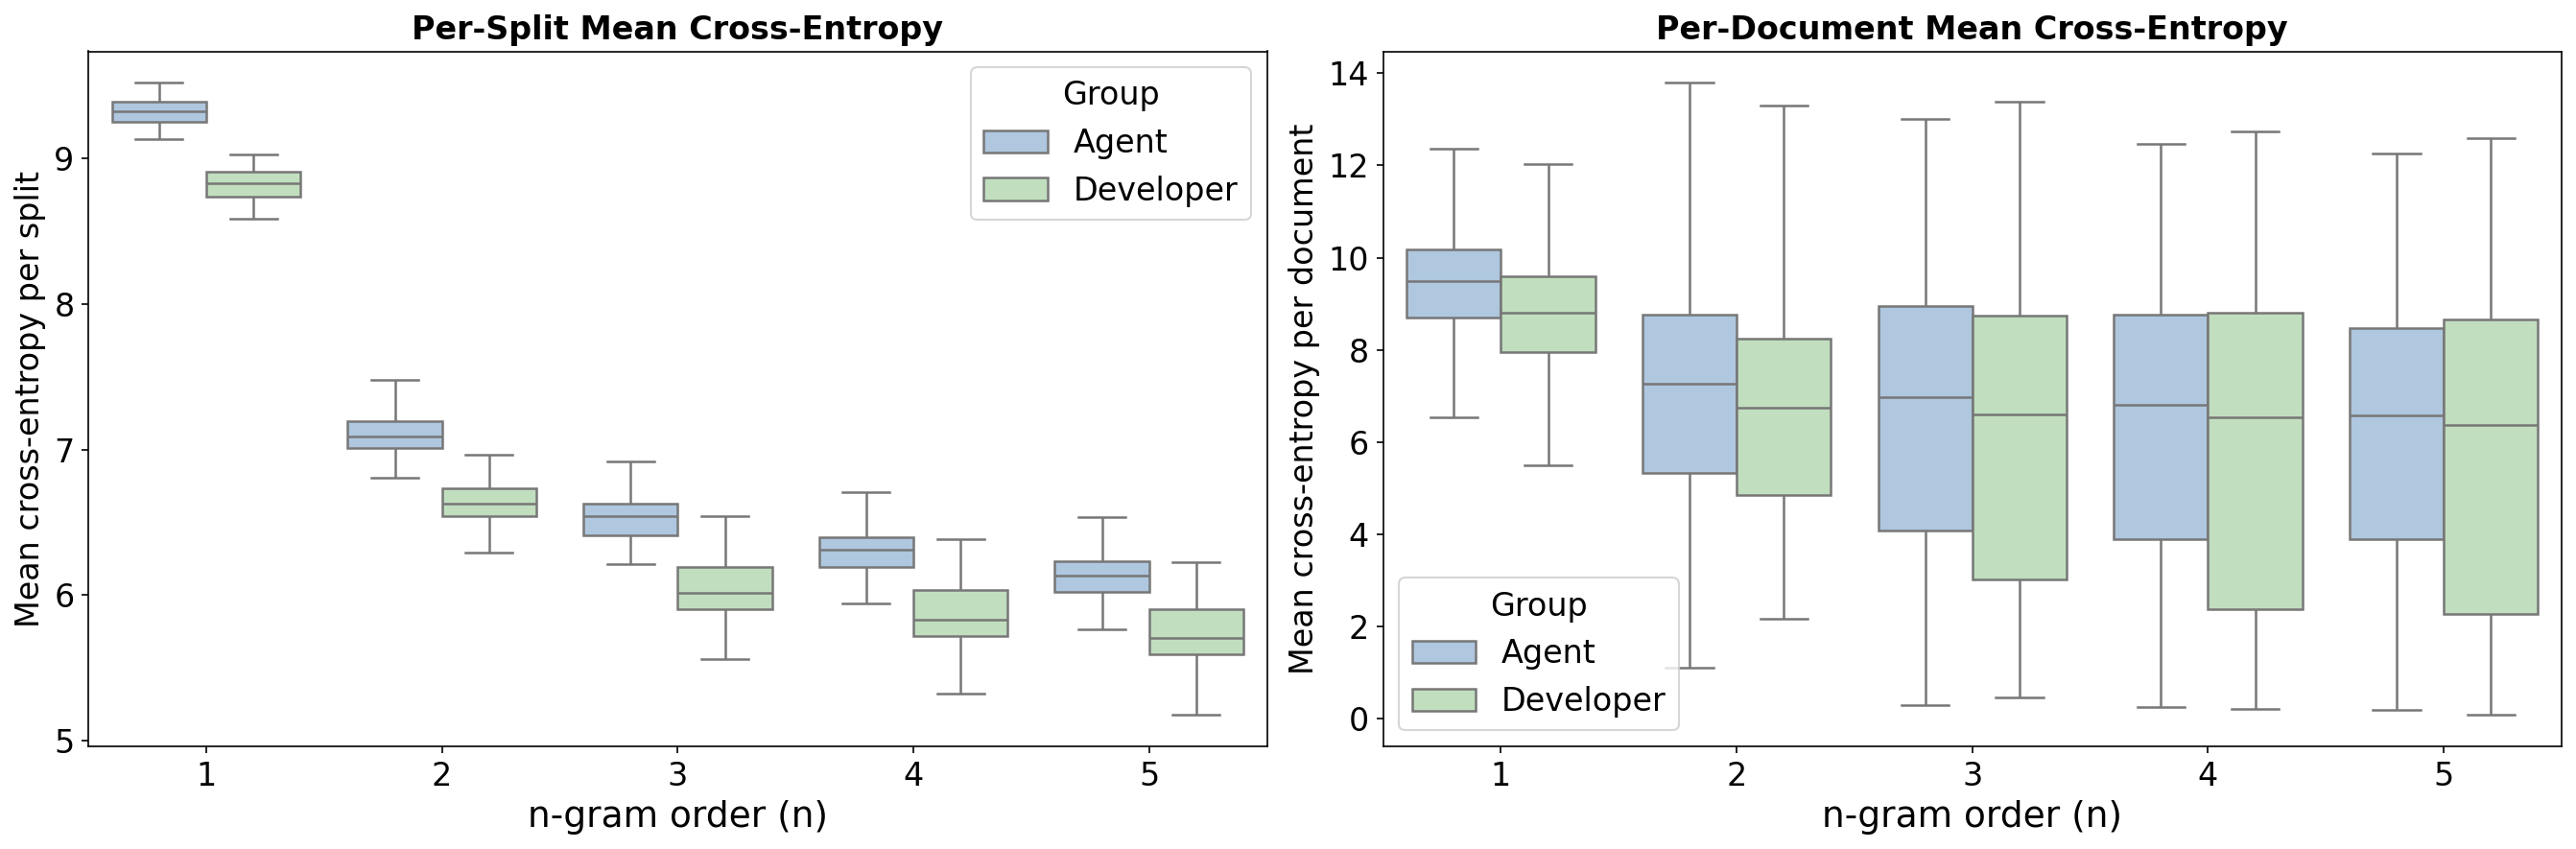


Mann-Whitney U (per-document collapse) and rank-biserial correlation:
  n=1: nag=3264 ndv=1952  p=4.6236e-61 ***  r_rb=-0.272
  n=2: nag=3264 ndv=1952  p=5.6526e-14 ***  r_rb=-0.124
  n=3: nag=3264 ndv=1952  p=1.0995e-08 ***  r_rb=-0.094
  n=4: nag=3264 ndv=1952  p=5.2092e-06 ***  r_rb=-0.075
  n=5: nag=3264 ndv=1952  p=8.2883e-05 ***  r_rb=-0.065

Per-split means :
  n=1: nag=100 ndv=100  p=2.5621e-34 ***  r_rb=-1.000
  n=2: nag=100 ndv=100  p=3.2242e-33 ***  r_rb=-0.983
  n=3: nag=100 ndv=100  p=3.5728e-31 ***  r_rb=-0.951
  n=4: nag=100 ndv=100  p=1.1052e-28 ***  r_rb=-0.910
  n=5: nag=100 ndv=100  p=8.3863e-27 ***  r_rb=-0.877

Per-document mean cross-entropy (bits) with 95% range [2.5th, 97.5th] percentile:
 n     Group   mean   p2_5   p97_5
 1     Agent 9.3324 5.0631 11.9687
 1 Developer 8.8135 5.7871 11.8842
 2     Agent 7.1329 3.1066 11.2701
 2 Developer 6.6593 2.7409 10.9208
 3     Agent 6.5755 1.5501 11.1843
 3 Developer 6.0546 0.9494 10.9115
 4     Agent 6.3554 1.2159 10.97

In [5]:
results = pd.read_csv("n_gram_cross_entropy.csv")
N_SPLITS = 100
def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def rank_biserial(x, y, U=None):
    """Rank-biserial correlation effect size for Mann-Whitney U (Wendt, 1972)."""
    if U is None:
        U, _ = mannwhitneyu(x, y, alternative="two-sided")
    return 1 - (2 * U) / (len(x) * len(y))

palette = {"Agent": "#A7C7E7", "Developer": "#BDE5B8"}


per_doc = (results
    .groupby(["n", "Group", "doc_id"])["cross_entropy"]
    .mean()
    .reset_index())

per_split = (results
    .groupby(["n", "Group", "Split"])["cross_entropy"]
    .mean()
    .reset_index())


fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=150)

sns.boxplot(
    data=per_split, x="n", y="cross_entropy", hue="Group",
    palette=palette, showfliers=False, linewidth=1.2,
    order=[1, 2, 3, 4, 5], ax=axes[0],
)
axes[0].set_xlabel("n-gram order (n)", fontsize=18)
axes[0].set_ylabel("Mean cross-entropy per split", fontsize=16)
axes[0].set_title("Per-Split Mean Cross-Entropy", fontsize=16, fontweight="bold")
axes[0].legend(title="Group", fontsize=16, title_fontsize=16)
axes[0].tick_params(axis="both", labelsize=16)

sns.boxplot(
    data=per_doc, x="n", y="cross_entropy", hue="Group",
    palette=palette, showfliers=False, linewidth=1.2,
    order=[1, 2, 3, 4, 5], ax=axes[1],
)
axes[1].set_xlabel("n-gram order (n)", fontsize=18)
axes[1].set_ylabel("Mean cross-entropy per document", fontsize=16)
axes[1].set_title("Per-Document Mean Cross-Entropy", fontsize=16, fontweight="bold")
axes[1].legend(title="Group", fontsize=16, title_fontsize=16)
axes[1].tick_params(axis="both", labelsize=16)

# fig.suptitle(
#     "N-gram Cross-Entropy: Agent vs. Developer Documentation ",
#     fontsize=20, fontweight="bold"
# )
plt.tight_layout()
plt.savefig("ngram_cross_entropy.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nMann-Whitney U (per-document collapse) and rank-biserial correlation:")
for n in range(1, 6):
    ag = per_doc[(per_doc["n"] == n) & (per_doc["Group"] == "Agent")]["cross_entropy"].values
    dv = per_doc[(per_doc["n"] == n) & (per_doc["Group"] == "Developer")]["cross_entropy"].values
    U, p = mannwhitneyu(ag, dv, alternative="two-sided")
    rbc = rank_biserial(ag, dv, U=U)
    print(f"  n={n}: nag={len(ag)} ndv={len(dv)}  p={p:.4e} {sig_label(p)}  r_rb={rbc:+.3f}")

print("\nPer-split means :")
for n in range(1, 6):
    ag = per_split[(per_split["n"] == n) & (per_split["Group"] == "Agent")]["cross_entropy"].values
    dv = per_split[(per_split["n"] == n) & (per_split["Group"] == "Developer")]["cross_entropy"].values
    U, p = mannwhitneyu(ag, dv, alternative="two-sided")
    rbc = rank_biserial(ag, dv, U=U)
    print(f"  n={n}: nag={len(ag)} ndv={len(dv)}  p={p:.4e} {sig_label(p)}  r_rb={rbc:+.3f}")


doc_summary = (
    per_doc.groupby(["n", "Group"])["cross_entropy"]
    .agg(
        mean="mean",
        p2_5=lambda s: s.quantile(0.025),
        p97_5=lambda s: s.quantile(0.975),
    )
    .round(4)
    .reset_index()
)

# stat table
stat_rows = []
for n in range(1, 6):
    ag = per_doc[(per_doc["n"] == n) & (per_doc["Group"] == "Agent")]["cross_entropy"].values
    dv = per_doc[(per_doc["n"] == n) & (per_doc["Group"] == "Developer")]["cross_entropy"].values
    U, p = mannwhitneyu(ag, dv, alternative="two-sided")
    rbc = rank_biserial(ag, dv, U=U)
    stat_rows.append({
        "n": n,
        "p-value": f"{p:.4e}",
        "sig": sig_label(p),
        "rank_biserial": round(rbc, 3),
    })
stat_summary = pd.DataFrame(stat_rows)

print("\nPer-document mean cross-entropy (bits) with 95% range [2.5th, 97.5th] percentile:")
print(doc_summary.to_string(index=False))

print("\nMann-Whitney U test (per-document collapse, Agent vs. Developer):")
print(stat_summary.to_string(index=False))



for n in range(1, 6):
    agent_means = []
    developer_means = []
    for split in range(1, N_SPLITS + 1): # get the means per split
        ag = per_split[(per_split["n"] == n) & (per_split["Group"] == "Agent") & (per_split["Split"] == split)]["cross_entropy"].values.mean()
        dv = per_split[(per_split["n"] == n) & (per_split["Group"] == "Developer") & (per_split["Split"] == split)]["cross_entropy"].values.mean()
        agent_means.append(ag)
        developer_means.append(dv)
    # 10,000 bootstrap sample with replacement
    n_bootstrap = 10000
    len_bootstrap = 100
    boot_diffs = []
    sig_diffs = []
    for _ in range(n_bootstrap):
        ag_sample = np.random.choice(agent_means, size=len_bootstrap, replace=True)
        dv_sample = np.random.choice(developer_means, size=len_bootstrap, replace=True)
        boot_diffs.append(ag_sample.mean() - dv_sample.mean())
        sig_diffs.append(mannwhitneyu(ag_sample, dv_sample, alternative="two-sided")[1])

    print(f"\nBootstrap difference of means (Agent - Developer) for n={n}:")
    mean_diff = np.mean(boot_diffs)
    ci_lower = np.percentile(boot_diffs, 2.5)
    ci_upper = np.percentile(boot_diffs, 97.5)
    print(f"Mean difference: {mean_diff:.4f}, 95% CI: [97.5th: {ci_upper:.4f}, 2.5th: {ci_lower:.4f}]")
    print(f"Proportion of significant differences (p < 0.05): {np.mean(np.array(sig_diffs) < 0.05):.4f}")